
# 🚔 FBI Crime Investigation Project
### Predicting Monthly Crime Incident Counts Using Spatiotemporal Data

**Business Context**

This project develops a predictive model that estimates monthly crime incident
counts using historical day/hour-level crime data (crime type, location,
neighborhood, and timestamps). The goal is to support law enforcement resource
allocation, patrol scheduling, and proactive public-safety planning.

**Data**
- `Train.xlsx` — 474,565 raw incident-level crime records (1999–2011) with crime
  type, neighborhood, latitude/longitude, and full timestamps.
- `Test.csv` — 162 rows representing every (Year, Month, Crime Type) combination
  for **Jan 2012 – Jun 2013**, with `Incident_Counts` to be predicted.

**Approach**
1. Exploratory Data Analysis (temporal + spatial patterns)
2. Aggregate raw incidents into a monthly time series per crime type
3. Feature engineering (lag features, rolling means, cyclical month encoding)
4. Model monthly counts per crime type using:
   - **XGBoost** (primary — pools information across all crime types)
   - **SARIMA** (comparison — classic seasonal time-series baseline)
5. Validate on a held-out year (2011), then forecast Test.csv's 2012–2013 period
6. Evaluate with MAE / RMSE / MAPE and visualize forecasts


## 1. Setup & Imports

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
from statsmodels.tsa.statespace.sarimax import SARIMAX

# ── Plot styling ──
plt.rcParams['figure.facecolor']  = '#0d1117'
plt.rcParams['axes.facecolor']    = '#161b22'
plt.rcParams['axes.edgecolor']    = '#30363d'
plt.rcParams['axes.labelcolor']   = '#c9d1d9'
plt.rcParams['xtick.color']       = '#8b949e'
plt.rcParams['ytick.color']       = '#8b949e'
plt.rcParams['text.color']        = '#c9d1d9'
plt.rcParams['grid.color']        = '#21262d'
plt.rcParams['axes.titlecolor']   = 'white'
plt.rcParams['legend.facecolor']  = '#161b22'
plt.rcParams['legend.edgecolor']  = '#30363d'
plt.rcParams['legend.labelcolor'] = 'white'
sns.set_style("darkgrid", {"axes.facecolor": "#161b22", "grid.color": "#21262d"})

PALETTE = ["#58a6ff","#3fb950","#f78166","#d2a8ff","#ffa657",
           "#ff7b72","#79c0ff","#56d364","#bc8cff"]

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)

print("Libraries loaded.")


Libraries loaded.


## 2. Load Data

In [ ]:

# Train: raw incident-level data (1999-2011)
train_raw = pd.read_excel("/mnt/user-data/uploads/Train.xlsx", engine="openpyxl")

# Test: the prediction template (2012-2013), Incident_Counts to be filled
test_df = pd.read_csv("/mnt/user-data/uploads/Test.csv")

print("Train shape:", train_raw.shape)
print("Test shape :", test_df.shape)
train_raw.head()


Train shape: (474565, 13)
Test shape : (162, 4)


,TYPE,HUNDRED_BLOCK,NEIGHBOURHOOD,X,Y,Latitude,Longitude,HOUR,MINUTE,YEAR,MONTH,DAY,Date
0,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,16.0,15.0,1999,5,12,1999-05-12
1,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,15.0,20.0,1999,5,7,1999-05-07
2,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,16.0,40.0,1999,4,23,1999-04-23
3,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,11.0,15.0,1999,4,20,1999-04-20
4,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,17.0,45.0,1999,4,12,1999-04-12


In [ ]:

test_df.head(10)


,YEAR,MONTH,TYPE,Incident_Counts
0,2013,6,Vehicle Collision or Pedestrian Struck (with I...,NaN
1,2013,6,Theft of Vehicle,NaN
2,2013,6,Theft of Bicycle,NaN
3,2013,6,Theft from Vehicle,NaN
4,2013,6,Other Theft,NaN
5,2013,6,Offence Against a Person,NaN
6,2013,6,Mischief,NaN
7,2013,6,Break and Enter Residential/Other,NaN
8,2013,6,Break and Enter Commercial,NaN
9,2013,5,Vehicle Collision or Pedestrian Struck (with I...,NaN


In [ ]:

print("Train date range :", train_raw['Date'].min(), "to", train_raw['Date'].max())
print("Train YEAR range :", train_raw['YEAR'].min(), "-", train_raw['YEAR'].max())
print("Test  YEAR range :", test_df['YEAR'].min(), "-", test_df['YEAR'].max())
print()
print("Crime types (Train):", sorted(train_raw['TYPE'].unique()))
print()
print("Missing values in Train:")
print(train_raw.isna().sum())
print()
print("Test Incident_Counts non-null count:", test_df['Incident_Counts'].notna().sum(), "/", len(test_df))


Train date range : 1999-01-01 00:00:00 to 2011-12-31 00:00:00
Train YEAR range : 1999 - 2011
Test  YEAR range : 2012 - 2013

Crime types (Train): ['Break and Enter Commercial', 'Break and Enter Residential/Other', 'Mischief', 'Offence Against a Person', 'Other Theft', 'Theft from Vehicle', 'Theft of Bicycle', 'Theft of Vehicle', 'Vehicle Collision or Pedestrian Struck (with Injury)']

Missing values in Train:
TYPE                 0
HUNDRED_BLOCK       13
NEIGHBOURHOOD    51491
X                    0
Y                    0
Latitude             0
Longitude            0
HOUR             49365
MINUTE           49365
YEAR                 0
MONTH                0
DAY                  0
Date                 0
dtype: int64

Test Incident_Counts non-null count: 0 / 162



## 3. Exploratory Data Analysis (EDA)

We examine the temporal distribution (by year, month, hour) and spatial
distribution (by neighborhood, lat/long) of crime incidents, along with
the relative frequency of each crime type.


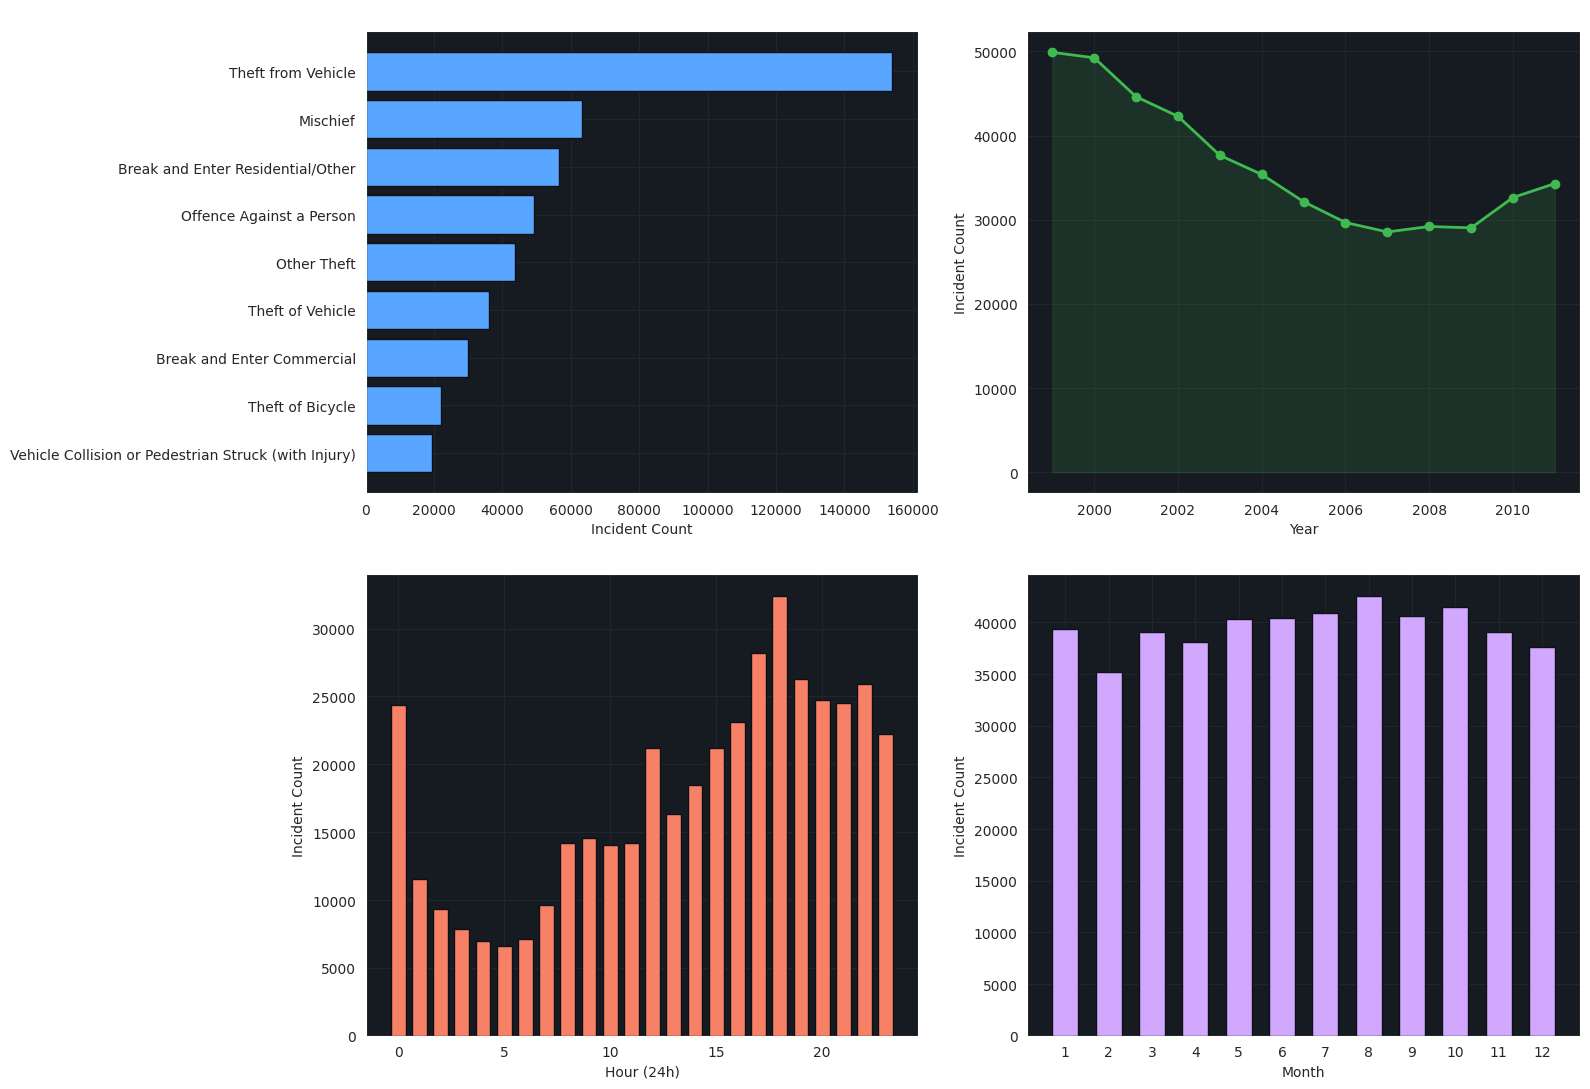

In [ ]:

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# 3.1 Crime type frequency
type_counts = train_raw['TYPE'].value_counts()
axes[0,0].barh(type_counts.index[::-1], type_counts.values[::-1],
               color=PALETTE[0], edgecolor="#0d1117")
axes[0,0].set_title("Total Incidents by Crime Type (1999-2011)", fontweight="bold")
axes[0,0].set_xlabel("Incident Count")

# 3.2 Incidents per year (trend)
yearly = train_raw.groupby('YEAR').size()
axes[0,1].plot(yearly.index, yearly.values, marker='o', color=PALETTE[1], linewidth=2)
axes[0,1].fill_between(yearly.index, yearly.values, alpha=0.15, color=PALETTE[1])
axes[0,1].set_title("Total Incidents per Year", fontweight="bold")
axes[0,1].set_xlabel("Year"); axes[0,1].set_ylabel("Incident Count")

# 3.3 Incidents by hour of day
hourly = train_raw['HOUR'].value_counts().sort_index()
axes[1,0].bar(hourly.index, hourly.values, color=PALETTE[2], edgecolor="#0d1117", width=0.7)
axes[1,0].set_title("Incidents by Hour of Day", fontweight="bold")
axes[1,0].set_xlabel("Hour (24h)"); axes[1,0].set_ylabel("Incident Count")

# 3.4 Incidents by month (seasonality)
monthly_season = train_raw.groupby('MONTH').size()
axes[1,1].bar(monthly_season.index, monthly_season.values, color=PALETTE[3], edgecolor="#0d1117", width=0.6)
axes[1,1].set_title("Total Incidents by Month (Seasonality, all years)", fontweight="bold")
axes[1,1].set_xlabel("Month"); axes[1,1].set_ylabel("Incident Count")
axes[1,1].set_xticks(range(1,13))

plt.tight_layout()
plt.show()


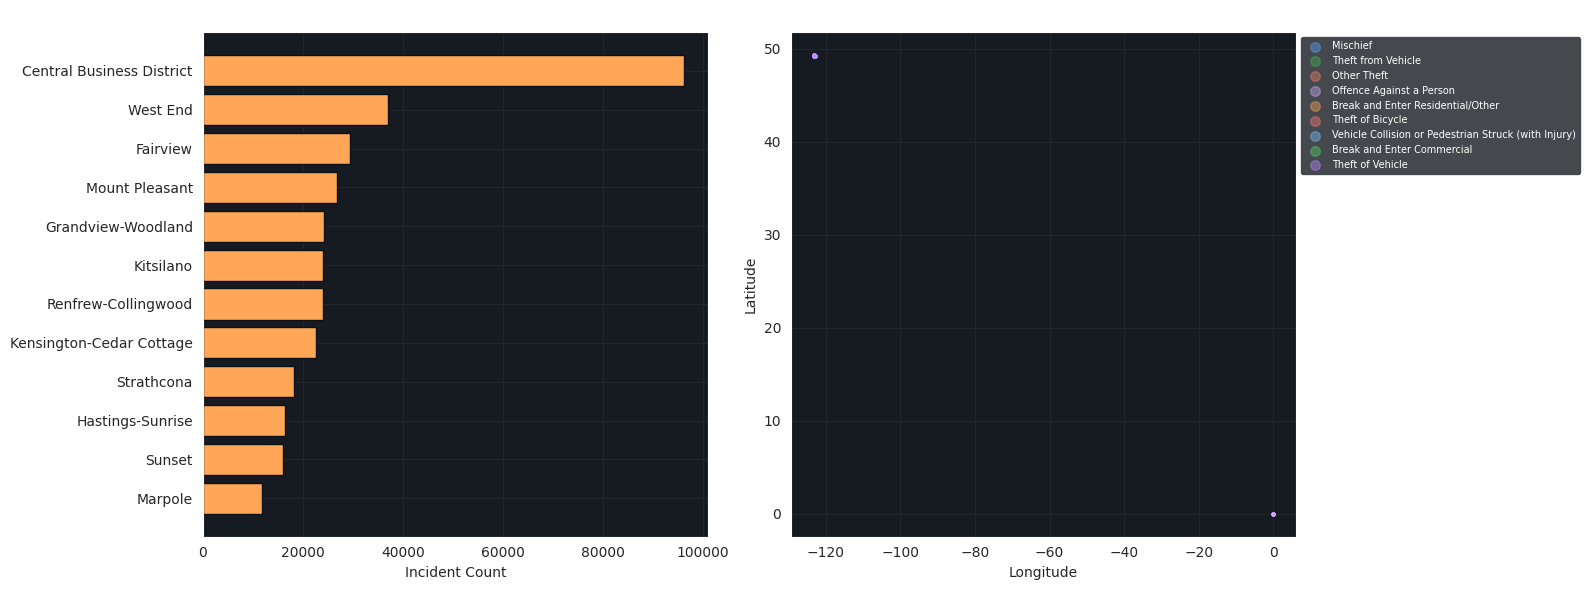

In [ ]:

# Top neighborhoods and spatial scatter
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_n = train_raw['NEIGHBOURHOOD'].value_counts().head(12)
axes[0].barh(top_n.index[::-1], top_n.values[::-1], color=PALETTE[4], edgecolor="#0d1117")
axes[0].set_title("Top 12 Neighborhoods by Incident Count", fontweight="bold")
axes[0].set_xlabel("Incident Count")

# Spatial scatter (sample for speed) colored by crime type
sample = train_raw.sample(15000, random_state=42)
types = sample['TYPE'].unique()
for i, t in enumerate(types):
    sub = sample[sample['TYPE']==t]
    axes[1].scatter(sub['Longitude'], sub['Latitude'], s=3, alpha=0.4,
                     color=PALETTE[i % len(PALETTE)], label=t)
axes[1].set_title("Spatial Distribution of Crimes (sampled, by type)", fontweight="bold")
axes[1].set_xlabel("Longitude"); axes[1].set_ylabel("Latitude")
axes[1].legend(markerscale=4, fontsize=7, loc='upper left', bbox_to_anchor=(1,1))

plt.tight_layout()
plt.show()


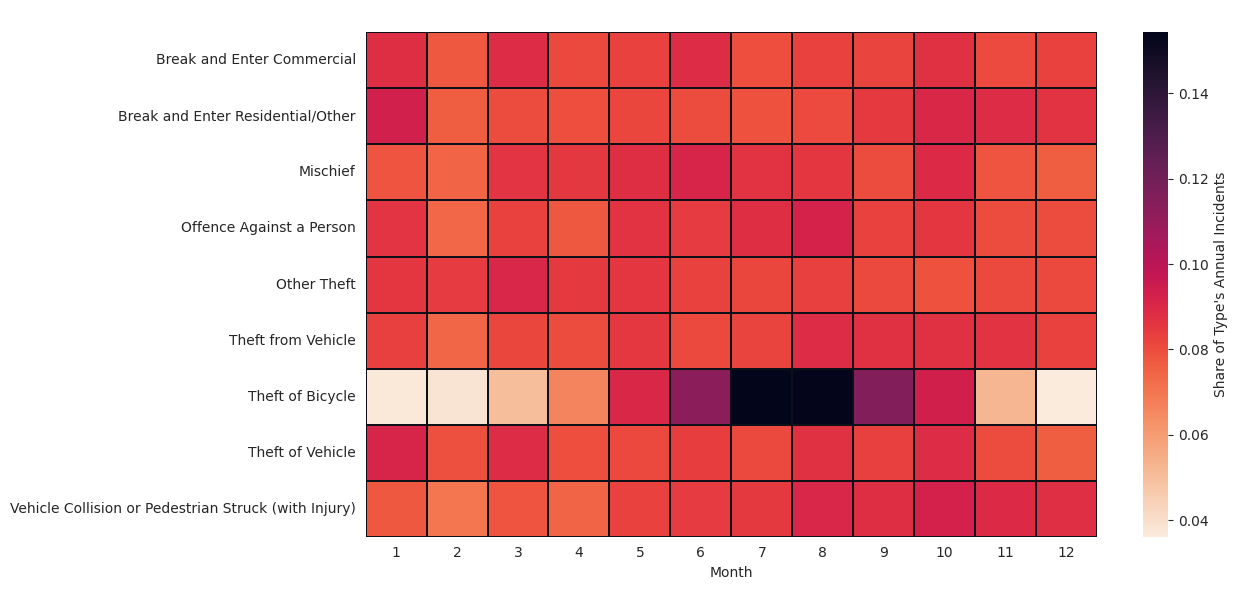

In [ ]:

# Heatmap: crime type vs month (seasonality per type)
type_month = train_raw.groupby(['TYPE','MONTH']).size().unstack(fill_value=0)
type_month_norm = type_month.div(type_month.sum(axis=1), axis=0)  # normalize per type

plt.figure(figsize=(13, 6))
sns.heatmap(type_month_norm, cmap="rocket_r", linewidths=0.3, linecolor="#0d1117",
            cbar_kws={'label': 'Share of Type\'s Annual Incidents'})
plt.title("Seasonal Pattern by Crime Type (normalized within type)", fontweight="bold", color="white")
plt.xlabel("Month"); plt.ylabel("")
plt.tight_layout()
plt.show()



## 4. Aggregate to Monthly Time Series

The model target is **monthly incident counts per crime type** (matching
`Test.csv`'s grain). We aggregate the raw incident-level data accordingly.


In [ ]:

monthly = (
    train_raw
    .groupby(['YEAR','MONTH','TYPE'])
    .size()
    .reset_index(name='Incident_Counts')
)
monthly['Date'] = pd.to_datetime(
    monthly['YEAR'].astype(str) + '-' + monthly['MONTH'].astype(str) + '-01'
)
monthly = monthly.sort_values(['TYPE','Date']).reset_index(drop=True)

print("Monthly series shape:", monthly.shape)
print("Expected (13 years x 12 months x 9 types):", 13*12*9)
monthly.head()


Monthly series shape: (1404, 5)
Expected (13 years x 12 months x 9 types): 1404


,YEAR,MONTH,TYPE,Incident_Counts,Date
0,1999,1,Break and Enter Commercial,303,1999-01-01
1,1999,2,Break and Enter Commercial,254,1999-02-01
2,1999,3,Break and Enter Commercial,292,1999-03-01
3,1999,4,Break and Enter Commercial,266,1999-04-01
4,1999,5,Break and Enter Commercial,291,1999-05-01


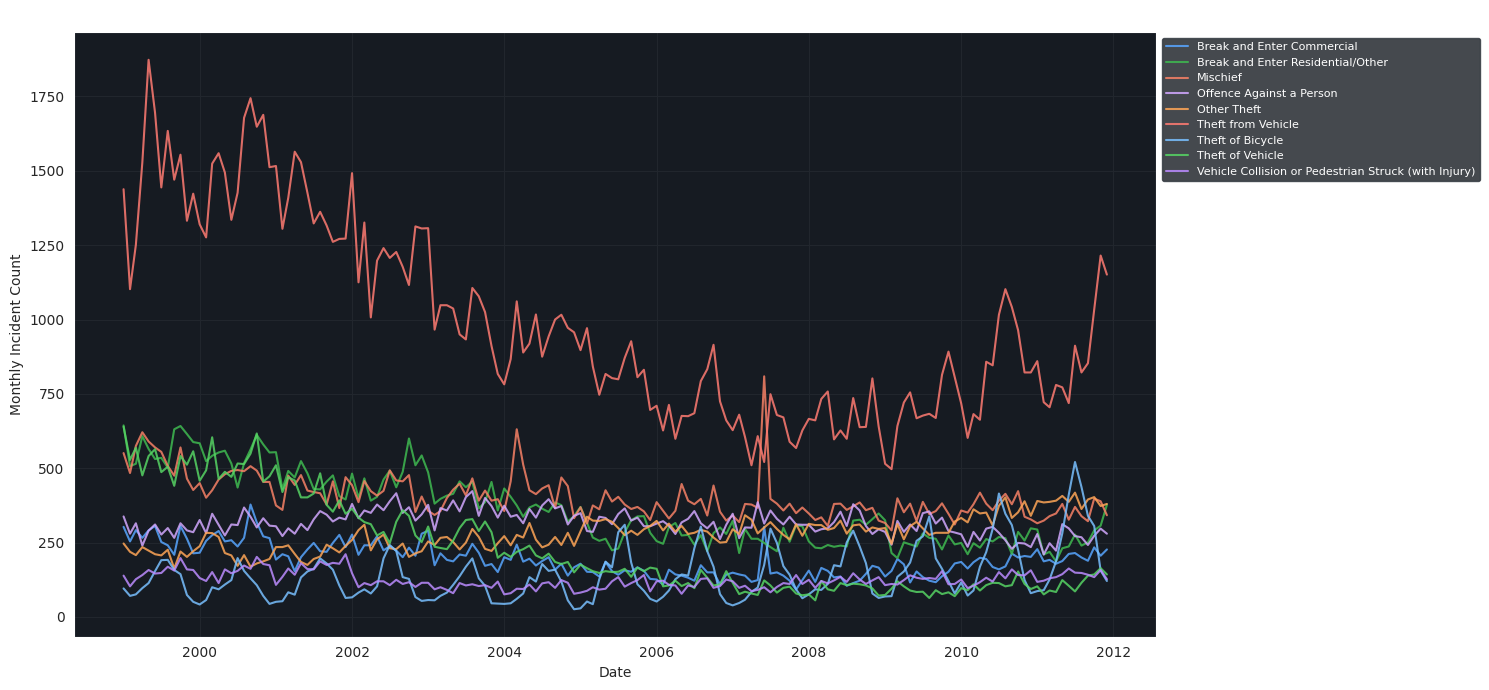

In [ ]:

# Visualize the monthly time series for each crime type
fig, ax = plt.subplots(figsize=(15, 7))
for i, t in enumerate(monthly['TYPE'].unique()):
    sub = monthly[monthly['TYPE']==t]
    ax.plot(sub['Date'], sub['Incident_Counts'], label=t,
            color=PALETTE[i % len(PALETTE)], linewidth=1.5, alpha=0.85)
ax.set_title("Monthly Incident Counts by Crime Type (1999-2011)", fontweight="bold")
ax.set_xlabel("Date"); ax.set_ylabel("Monthly Incident Count")
ax.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1, 1))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
plt.tight_layout()
plt.show()



## 5. Feature Engineering

For the **XGBoost** model we engineer:
- **Cyclical month encoding** (`sin`/`cos`) so December and January are
  recognized as adjacent rather than far apart numerically
- **Linear time index** to capture long-term trend
- **Lag features** (t-1, t-2, t-3, t-12) — last month, two/three months ago,
  and same month last year (captures yearly seasonality directly)
- **Rolling means** (3-month, 12-month) — smoothed recent trend level
- **Crime type** as one-hot encoded categorical, so a single model learns
  shared temporal patterns while still distinguishing each type's baseline


In [ ]:

def add_features(d: pd.DataFrame) -> pd.DataFrame:
    d = d.copy()
    d['month_sin'] = np.sin(2*np.pi*d['MONTH']/12)
    d['month_cos'] = np.cos(2*np.pi*d['MONTH']/12)
    d['time_idx']  = (d['YEAR'] - d['YEAR'].min())*12 + d['MONTH']
    for lag in [1, 2, 3, 12]:
        d[f'lag_{lag}'] = d.groupby('TYPE')['Incident_Counts'].shift(lag)
    d['rolling_mean_3']  = d.groupby('TYPE')['Incident_Counts'] \
                             .transform(lambda x: x.shift(1).rolling(3).mean())
    d['rolling_mean_12'] = d.groupby('TYPE')['Incident_Counts'] \
                             .transform(lambda x: x.shift(1).rolling(12).mean())
    return d

monthly_feat = add_features(monthly)
FEATURE_COLS = ['MONTH','month_sin','month_cos','time_idx',
                 'lag_1','lag_2','lag_3','lag_12',
                 'rolling_mean_3','rolling_mean_12']
ALL_TYPES = sorted(monthly['TYPE'].unique())

monthly_feat[monthly_feat['TYPE']=='Mischief'].tail(8)[
    ['YEAR','MONTH','Incident_Counts'] + FEATURE_COLS
]


,YEAR,MONTH,Incident_Counts,MONTH,month_sin,month_cos,time_idx,lag_1,lag_2,lag_3,lag_12,rolling_mean_3,rolling_mean_12
460,2011,5,380,5,5.000000e-01,-8.660254e-01,149,348.0,339.0,324.0,381.0,337.000000,361.500000
461,2011,6,327,6,1.224647e-16,-1.000000e+00,150,380.0,348.0,339.0,359.0,355.666667,361.416667
462,2011,7,370,7,-5.000000e-01,-8.660254e-01,151,327.0,380.0,348.0,391.0,351.666667,358.750000
463,2011,8,339,8,-8.660254e-01,-5.000000e-01,152,370.0,327.0,380.0,414.0,359.000000,357.000000
464,2011,9,322,9,-1.000000e+00,-1.836970e-16,153,339.0,370.0,327.0,379.0,345.333333,350.750000
465,2011,10,398,10,-8.660254e-01,5.000000e-01,154,322.0,339.0,370.0,423.0,343.666667,346.000000
466,2011,11,389,11,-5.000000e-01,8.660254e-01,155,398.0,322.0,339.0,337.0,353.000000,343.916667
467,2011,12,342,12,-2.449294e-16,1.000000e+00,156,389.0,398.0,322.0,328.0,369.666667,348.250000



## 6. Model 1 — XGBoost (Primary Model)

We hold out **2011** (the last full year of `Train.xlsx`) as a validation
set, train on 1999–2010, and forecast 2011 **recursively** — i.e. each
month's prediction feeds into the lag features for the next month. This
mirrors exactly how we'll need to forecast the real 2012–2013 test period,
where true future values don't exist yet.


In [ ]:

def build_design_matrix(df_feat, type_list):
    # One-hot encode TYPE and align columns
    dummies = pd.get_dummies(df_feat['TYPE'], prefix='type')
    for t in type_list:
        col = f'type_{t}'
        if col not in dummies.columns:
            dummies[col] = 0
    dummies = dummies[[f'type_{t}' for t in type_list]]
    X = pd.concat([df_feat[FEATURE_COLS].reset_index(drop=True),
                    dummies.reset_index(drop=True)], axis=1)
    return X

train_window = monthly_feat[monthly_feat['Date'] < '2011-01-01'].dropna(subset=FEATURE_COLS)
X_train = build_design_matrix(train_window, ALL_TYPES)
y_train = train_window['Incident_Counts'].reset_index(drop=True)

print("Training matrix:", X_train.shape)

xgb_model = xgb.XGBRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9,
    random_state=42, objective='reg:squarederror'
)
xgb_model.fit(X_train, y_train)
print("XGBoost model trained.")


Training matrix: (1188, 19)
XGBoost model trained.


In [ ]:

def recursive_forecast_xgb(model, history_df, forecast_dates, type_list):
    # Recursively forecast monthly incident counts per crime type.
    # history_df must contain ['YEAR','MONTH','TYPE','Date','Incident_Counts'].
    hist = history_df.copy()
    preds = []
    for dt in forecast_dates:
        rows = []
        for t in type_list:
            sub = hist[hist['TYPE']==t].sort_values('Date')
            vals = sub['Incident_Counts'].values
            lag_1  = vals[-1]  if len(vals) >= 1  else np.nan
            lag_2  = vals[-2]  if len(vals) >= 2  else np.nan
            lag_3  = vals[-3]  if len(vals) >= 3  else np.nan
            lag_12 = vals[-12] if len(vals) >= 12 else np.nan
            roll3  = vals[-3:].mean()  if len(vals) >= 3  else np.nan
            roll12 = vals[-12:].mean() if len(vals) >= 12 else np.nan
            rows.append({
                'YEAR': dt.year, 'MONTH': dt.month, 'TYPE': t, 'Date': dt,
                'month_sin': np.sin(2*np.pi*dt.month/12),
                'month_cos': np.cos(2*np.pi*dt.month/12),
                'time_idx': (dt.year - history_df['YEAR'].min())*12 + dt.month,
                'lag_1': lag_1, 'lag_2': lag_2, 'lag_3': lag_3, 'lag_12': lag_12,
                'rolling_mean_3': roll3, 'rolling_mean_12': roll12,
            })
        batch = pd.DataFrame(rows)
        X_batch = build_design_matrix(batch, type_list)
        batch['Incident_Counts'] = np.maximum(0, model.predict(X_batch))
        preds.append(batch[['YEAR','MONTH','TYPE','Date','Incident_Counts']])
        hist = pd.concat([hist, batch[['YEAR','MONTH','TYPE','Date','Incident_Counts']]],
                          ignore_index=True)
    return pd.concat(preds, ignore_index=True)

# Validate recursively on 2011
val_dates = pd.date_range('2011-01-01', '2011-12-01', freq='MS')
history_for_val = monthly[monthly['Date'] < '2011-01-01'][['YEAR','MONTH','TYPE','Date','Incident_Counts']]

xgb_val_preds = recursive_forecast_xgb(xgb_model, history_for_val, val_dates, ALL_TYPES)
xgb_val_actual = monthly[(monthly['Date']>='2011-01-01') & (monthly['Date']<'2012-01-01')]

xgb_val_merged = xgb_val_preds.merge(
    xgb_val_actual[['YEAR','MONTH','TYPE','Incident_Counts']],
    on=['YEAR','MONTH','TYPE'], suffixes=('_pred','_actual')
)

xgb_mae  = mean_absolute_error(xgb_val_merged['Incident_Counts_actual'], xgb_val_merged['Incident_Counts_pred'])
xgb_rmse = np.sqrt(mean_squared_error(xgb_val_merged['Incident_Counts_actual'], xgb_val_merged['Incident_Counts_pred']))
xgb_mape = np.mean(np.abs((xgb_val_merged['Incident_Counts_actual'] - xgb_val_merged['Incident_Counts_pred'])
                            / xgb_val_merged['Incident_Counts_actual'])) * 100

print(f"XGBoost 2011 Holdout Validation:")
print(f"  MAE  : {xgb_mae:.2f}")
print(f"  RMSE : {xgb_rmse:.2f}")
print(f"  MAPE : {xgb_mape:.2f}%")


XGBoost 2011 Holdout Validation:
  MAE  : 46.23
  RMSE : 74.10
  MAPE : 14.20%


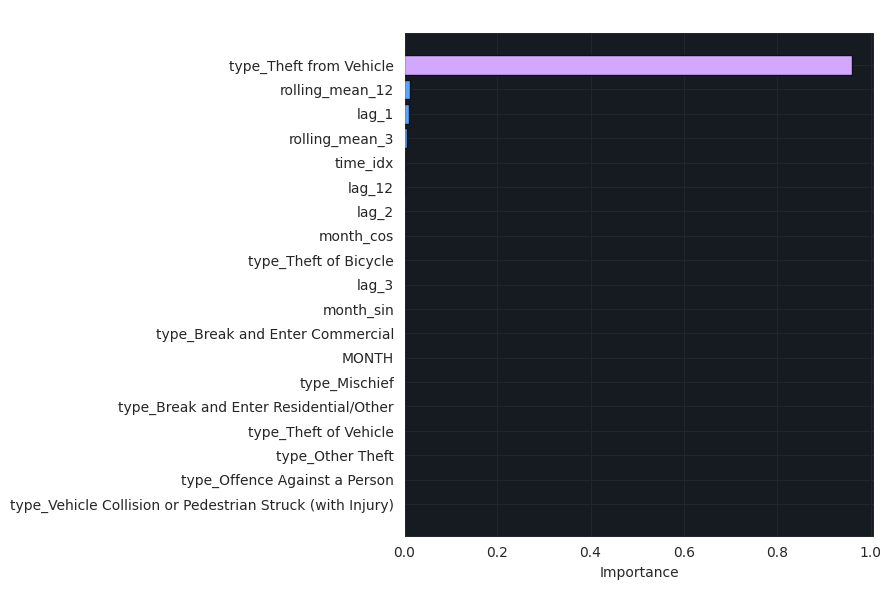

In [ ]:

# Feature importance
fig, ax = plt.subplots(figsize=(9, 6))
importances = pd.Series(xgb_model.feature_importances_, index=X_train.columns).sort_values()
colors_imp = [PALETTE[0] if 'type_' not in f else PALETTE[3] for f in importances.index]
ax.barh(importances.index, importances.values, color=colors_imp, edgecolor="#0d1117")
ax.set_title("XGBoost Feature Importances", fontweight="bold")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()



## 7. Model 2 — SARIMA (Comparison Baseline)

SARIMA models each crime type as an **independent univariate series**
with seasonal differencing — a classical, interpretable approach well
suited to data with clear yearly seasonality. We fit one SARIMA model
per crime type and validate the same way (forecast 2011 from 1999–2010).


In [ ]:

sarima_results = {}
sarima_val_records = []

for t in ALL_TYPES:
    series = monthly[monthly['TYPE']==t].sort_values('Date').set_index('Date')['Incident_Counts']
    series.index.freq = 'MS'
    train_s = series[series.index < '2011-01-01']
    val_s   = series[(series.index >= '2011-01-01') & (series.index < '2012-01-01')]

    model = SARIMAX(train_s, order=(1,1,1), seasonal_order=(1,1,1,12),
                     enforce_stationarity=False, enforce_invertibility=False)
    fit = model.fit(disp=False)
    fc = fit.forecast(steps=12)
    fc = fc.clip(lower=0)

    sarima_results[t] = fit
    for dt, pred, actual in zip(val_s.index, fc.values, val_s.values):
        sarima_val_records.append({'TYPE': t, 'Date': dt, 'YEAR': dt.year, 'MONTH': dt.month,
                                    'Incident_Counts_pred': pred, 'Incident_Counts_actual': actual})

sarima_val_df = pd.DataFrame(sarima_val_records)

sarima_mae  = mean_absolute_error(sarima_val_df['Incident_Counts_actual'], sarima_val_df['Incident_Counts_pred'])
sarima_rmse = np.sqrt(mean_squared_error(sarima_val_df['Incident_Counts_actual'], sarima_val_df['Incident_Counts_pred']))
sarima_mape = np.mean(np.abs((sarima_val_df['Incident_Counts_actual'] - sarima_val_df['Incident_Counts_pred'])
                               / sarima_val_df['Incident_Counts_actual'])) * 100

print(f"SARIMA 2011 Holdout Validation (avg across all 9 types):")
print(f"  MAE  : {sarima_mae:.2f}")
print(f"  RMSE : {sarima_rmse:.2f}")
print(f"  MAPE : {sarima_mape:.2f}%")


SARIMA 2011 Holdout Validation (avg across all 9 types):
  MAE  : 38.15
  RMSE : 62.42
  MAPE : 11.71%


## 8. Model Comparison — XGBoost vs. SARIMA

,Model,MAE,RMSE,MAPE (%)
0,XGBoost (pooled),46.230835,74.096818,14.199798
1,SARIMA (per-type),38.147211,62.422909,11.711666


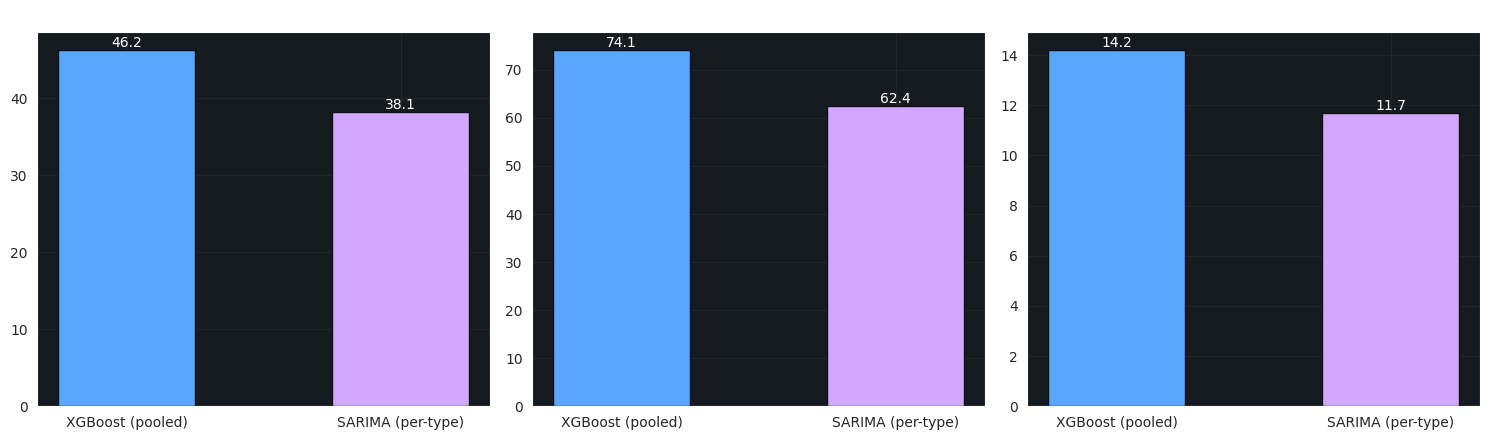

In [ ]:

comparison = pd.DataFrame({
    'Model': ['XGBoost (pooled)', 'SARIMA (per-type)'],
    'MAE':  [xgb_mae,  sarima_mae],
    'RMSE': [xgb_rmse, sarima_rmse],
    'MAPE (%)': [xgb_mape, sarima_mape],
})
display(comparison)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
metrics = ['MAE','RMSE','MAPE (%)']
for ax, m, col in zip(axes, metrics, [PALETTE[0], PALETTE[2], PALETTE[4]]):
    ax.bar(comparison['Model'], comparison[m], color=[PALETTE[0], PALETTE[3]], edgecolor="#0d1117", width=0.5)
    ax.set_title(m, fontweight="bold")
    for i, v in enumerate(comparison[m]):
        ax.text(i, v, f"{v:.1f}", ha='center', va='bottom', color='white', fontsize=10)
plt.tight_layout()
plt.show()


In [ ]:

# Per-type comparison: which model wins on which crime type?
xgb_per_type = xgb_val_merged.groupby('TYPE').apply(
    lambda d: mean_absolute_error(d['Incident_Counts_actual'], d['Incident_Counts_pred'])
).rename('XGBoost_MAE')

sarima_per_type = sarima_val_df.groupby('TYPE').apply(
    lambda d: mean_absolute_error(d['Incident_Counts_actual'], d['Incident_Counts_pred'])
).rename('SARIMA_MAE')

per_type_compare = pd.concat([xgb_per_type, sarima_per_type], axis=1)
per_type_compare['Better_Model'] = np.where(
    per_type_compare['XGBoost_MAE'] < per_type_compare['SARIMA_MAE'], 'XGBoost', 'SARIMA'
)
display(per_type_compare.sort_values('XGBoost_MAE'))


,XGBoost_MAE,SARIMA_MAE,Better_Model
TYPE,,,
Break and Enter Commercial,16.872646,26.500703,XGBoost
Theft of Vehicle,19.751831,24.849620,XGBoost
Vehicle Collision or Pedestrian Struck (with Injury),25.930883,10.122735,SARIMA
Other Theft,28.150976,25.593484,SARIMA
Offence Against a Person,28.587364,25.410246,SARIMA
Break and Enter Residential/Other,37.398144,32.722425,SARIMA
Mischief,39.328537,24.797074,SARIMA
Theft of Bicycle,53.534107,59.724684,XGBoost
Theft from Vehicle,166.523010,113.603927,SARIMA



## 9. Final Forecast — Predicting `Test.csv` (Jan 2012 – Jun 2013)

Based on the validation results above, we select the **better-performing
model per crime type** (a simple ensembling strategy) to generate the
final predictions, using the *entire* 1999–2011 training history.


In [ ]:

# Re-fit XGBoost on the FULL training history (1999-2011)
full_train_feat = monthly_feat.dropna(subset=FEATURE_COLS)
X_full = build_design_matrix(full_train_feat, ALL_TYPES)
y_full = full_train_feat['Incident_Counts'].reset_index(drop=True)

xgb_final = xgb.XGBRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9,
    random_state=42, objective='reg:squarederror'
)
xgb_final.fit(X_full, y_full)

# Forecast dates required by Test.csv
test_dates = sorted(pd.to_datetime(
    test_df['YEAR'].astype(str) + '-' + test_df['MONTH'].astype(str) + '-01'
).unique())

full_history = monthly[['YEAR','MONTH','TYPE','Date','Incident_Counts']]
xgb_final_preds = recursive_forecast_xgb(xgb_final, full_history, test_dates, ALL_TYPES)

print(f"Generated {len(xgb_final_preds)} XGBoost forecasts for the test period.")
xgb_final_preds.head()


Generated 162 XGBoost forecasts for the test period.


,YEAR,MONTH,TYPE,Date,Incident_Counts
0,2012,1,Break and Enter Commercial,2012-01-01,236.754227
1,2012,1,Break and Enter Residential/Other,2012-01-01,355.612091
2,2012,1,Mischief,2012-01-01,392.594055
3,2012,1,Offence Against a Person,2012-01-01,302.768585
4,2012,1,Other Theft,2012-01-01,405.300323


In [ ]:

# Re-fit SARIMA per type on full history and forecast the same horizon
n_steps = len(test_dates)
sarima_final_preds = []

for t in ALL_TYPES:
    series = monthly[monthly['TYPE']==t].sort_values('Date').set_index('Date')['Incident_Counts']
    series.index.freq = 'MS'
    model = SARIMAX(series, order=(1,1,1), seasonal_order=(1,1,1,12),
                     enforce_stationarity=False, enforce_invertibility=False)
    fit = model.fit(disp=False)
    fc = fit.forecast(steps=n_steps).clip(lower=0)
    for dt, pred in zip(test_dates, fc.values):
        sarima_final_preds.append({'YEAR': dt.year, 'MONTH': dt.month, 'TYPE': t, 'Incident_Counts': pred})

sarima_final_df = pd.DataFrame(sarima_final_preds)
print(f"Generated {len(sarima_final_df)} SARIMA forecasts for the test period.")
sarima_final_df.head()


Generated 162 SARIMA forecasts for the test period.


,YEAR,MONTH,TYPE,Incident_Counts
0,2012,1,Break and Enter Commercial,218.784315
1,2012,2,Break and Enter Commercial,191.051037
2,2012,3,Break and Enter Commercial,215.413641
3,2012,4,Break and Enter Commercial,198.198650
4,2012,5,Break and Enter Commercial,201.531037


In [ ]:

# Ensemble: use whichever model performed better on validation, per crime type
best_model_per_type = per_type_compare['Better_Model'].to_dict()

final_preds = []
for t in ALL_TYPES:
    if best_model_per_type[t] == 'XGBoost':
        sub = xgb_final_preds[xgb_final_preds['TYPE']==t][['YEAR','MONTH','TYPE','Incident_Counts']]
    else:
        sub = sarima_final_df[sarima_final_df['TYPE']==t][['YEAR','MONTH','TYPE','Incident_Counts']]
    final_preds.append(sub)

final_predictions = pd.concat(final_preds, ignore_index=True)
final_predictions['Incident_Counts'] = final_predictions['Incident_Counts'].round().astype(int)

print("Final blended predictions:")
final_predictions.head(10)


Final blended predictions:


,YEAR,MONTH,TYPE,Incident_Counts
0,2012,1,Break and Enter Commercial,237
1,2012,2,Break and Enter Commercial,227
2,2012,3,Break and Enter Commercial,233
3,2012,4,Break and Enter Commercial,225
4,2012,5,Break and Enter Commercial,233
5,2012,6,Break and Enter Commercial,239
6,2012,7,Break and Enter Commercial,253
7,2012,8,Break and Enter Commercial,257
8,2012,9,Break and Enter Commercial,246
9,2012,10,Break and Enter Commercial,262


In [ ]:

# Fill Test.csv with our predictions
test_filled = test_df.drop(columns=['Incident_Counts']).merge(
    final_predictions, on=['YEAR','MONTH','TYPE'], how='left'
)

print("Any unmatched rows?", test_filled['Incident_Counts'].isna().sum())
test_filled.head(10)


Any unmatched rows? 0


,YEAR,MONTH,TYPE,Incident_Counts
0,2013,6,Vehicle Collision or Pedestrian Struck (with I...,144
1,2013,6,Theft of Vehicle,146
2,2013,6,Theft of Bicycle,428
3,2013,6,Theft from Vehicle,1008
4,2013,6,Other Theft,429
5,2013,6,Offence Against a Person,277
6,2013,6,Mischief,361
7,2013,6,Break and Enter Residential/Other,244
8,2013,6,Break and Enter Commercial,272
9,2013,5,Vehicle Collision or Pedestrian Struck (with I...,139


In [ ]:

# Save final predictions
test_filled.to_csv('/mnt/user-data/outputs/Test_predictions.csv', index=False)
print("Saved to Test_predictions.csv")
test_filled.tail(10)


Saved to Test_predictions.csv


,YEAR,MONTH,TYPE,Incident_Counts
152,2012,2,Break and Enter Commercial,227
153,2012,1,Vehicle Collision or Pedestrian Struck (with I...,128
154,2012,1,Theft of Vehicle,132
155,2012,1,Theft of Bicycle,115
156,2012,1,Theft from Vehicle,1032
157,2012,1,Other Theft,409
158,2012,1,Offence Against a Person,280
159,2012,1,Mischief,313
160,2012,1,Break and Enter Residential/Other,327
161,2012,1,Break and Enter Commercial,237


## 10. Visualize Final Forecasts

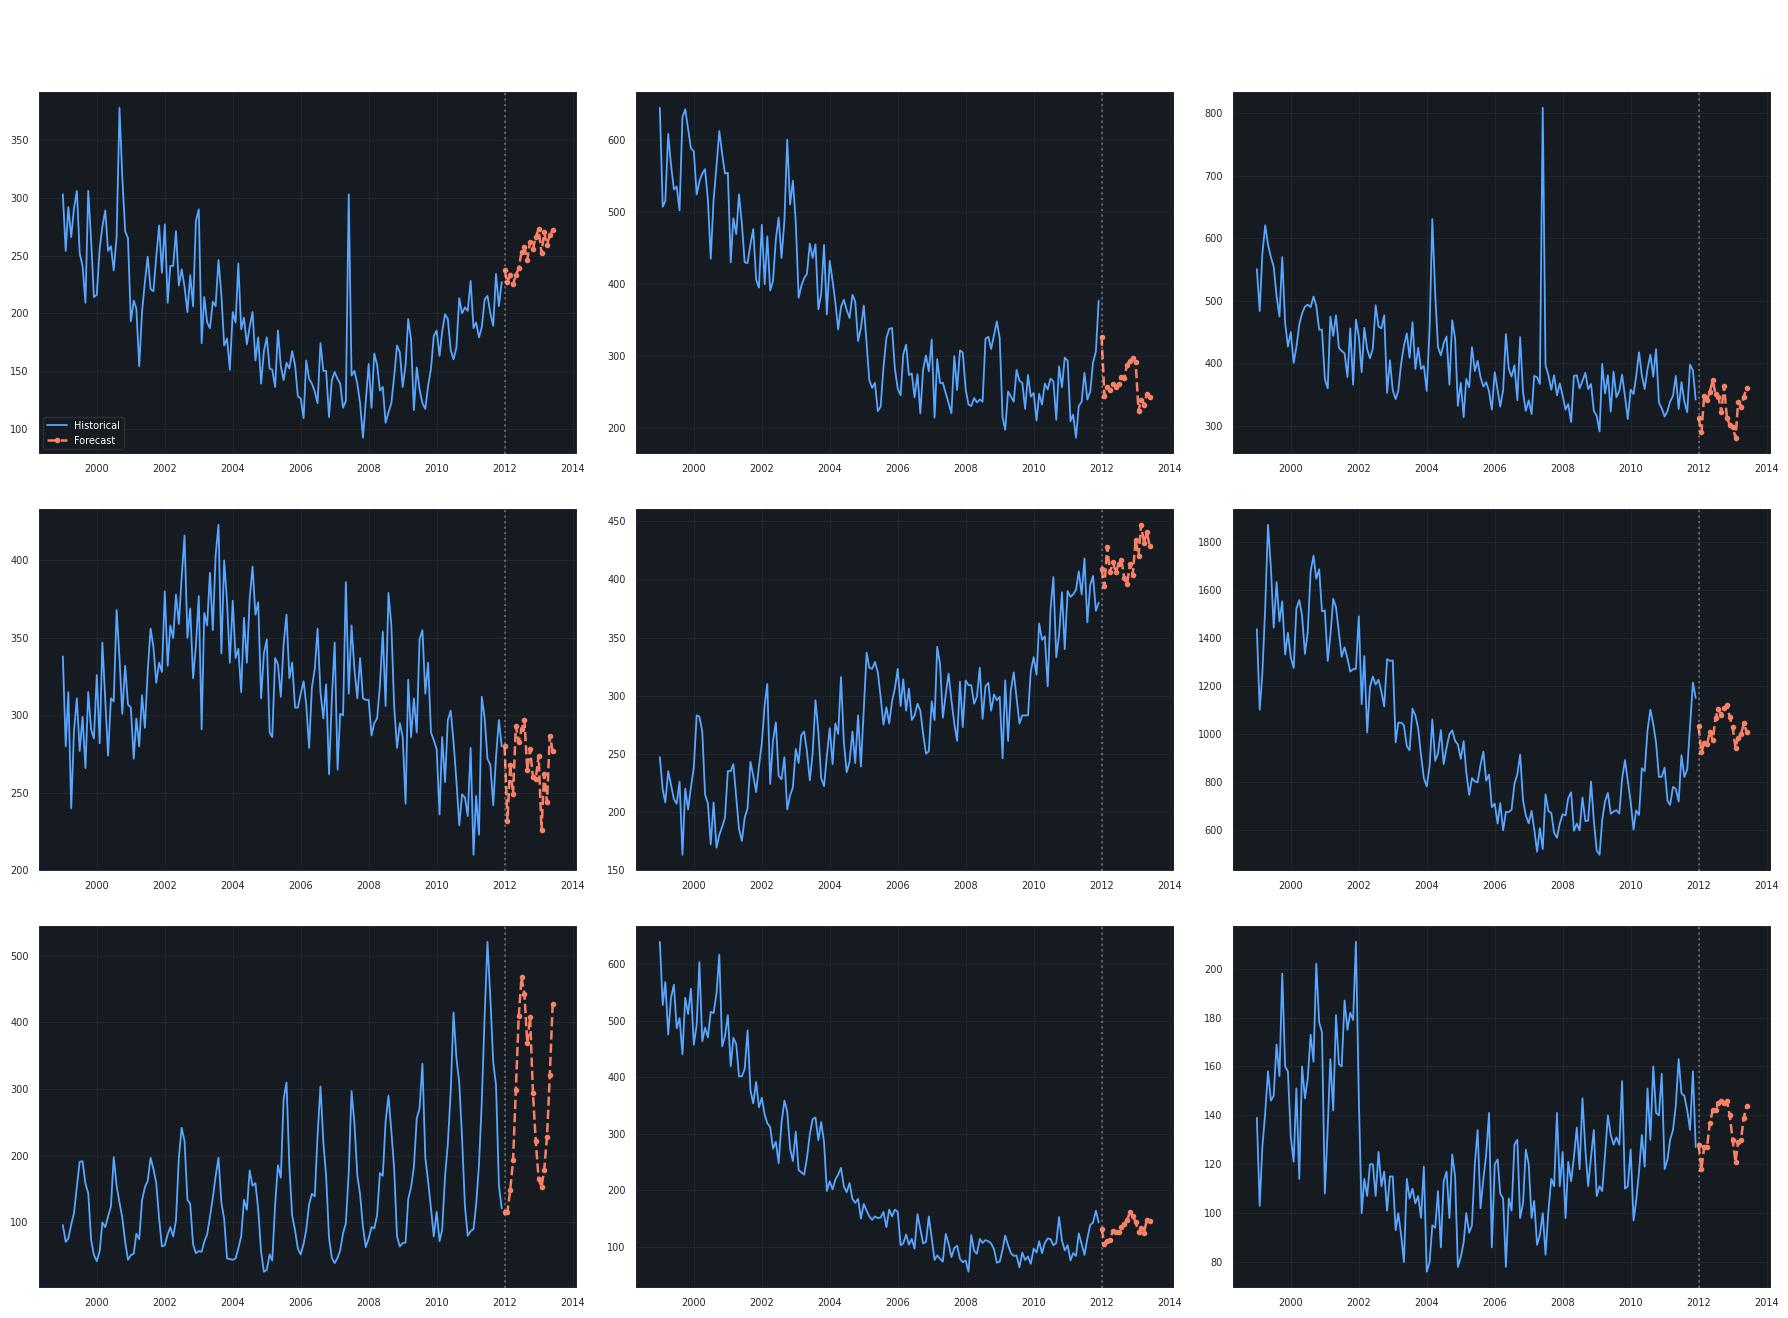

In [ ]:

fig, axes = plt.subplots(3, 3, figsize=(18, 13))
axes = axes.flatten()

for i, t in enumerate(ALL_TYPES):
    ax = axes[i]
    hist_t = monthly[monthly['TYPE']==t]
    fc_t   = test_filled[test_filled['TYPE']==t].copy()
    fc_t['Date'] = pd.to_datetime(fc_t['YEAR'].astype(str)+'-'+fc_t['MONTH'].astype(str)+'-01')
    fc_t = fc_t.sort_values('Date')

    ax.plot(hist_t['Date'], hist_t['Incident_Counts'], color=PALETTE[0], linewidth=1.3, label='Historical')
    ax.plot(fc_t['Date'], fc_t['Incident_Counts'], color=PALETTE[2], linewidth=1.8,
            linestyle='--', marker='o', markersize=3, label='Forecast')
    ax.axvline(pd.Timestamp('2012-01-01'), color='white', alpha=0.3, linestyle=':')
    ax.set_title(t, fontsize=10, fontweight="bold")
    ax.tick_params(labelsize=7)
    if i == 0:
        ax.legend(fontsize=7)

plt.suptitle("Historical Data (1999-2011) + Forecast (2012-2013) by Crime Type",
             fontsize=14, fontweight="bold", color="white", y=1.01)
plt.tight_layout()
plt.show()


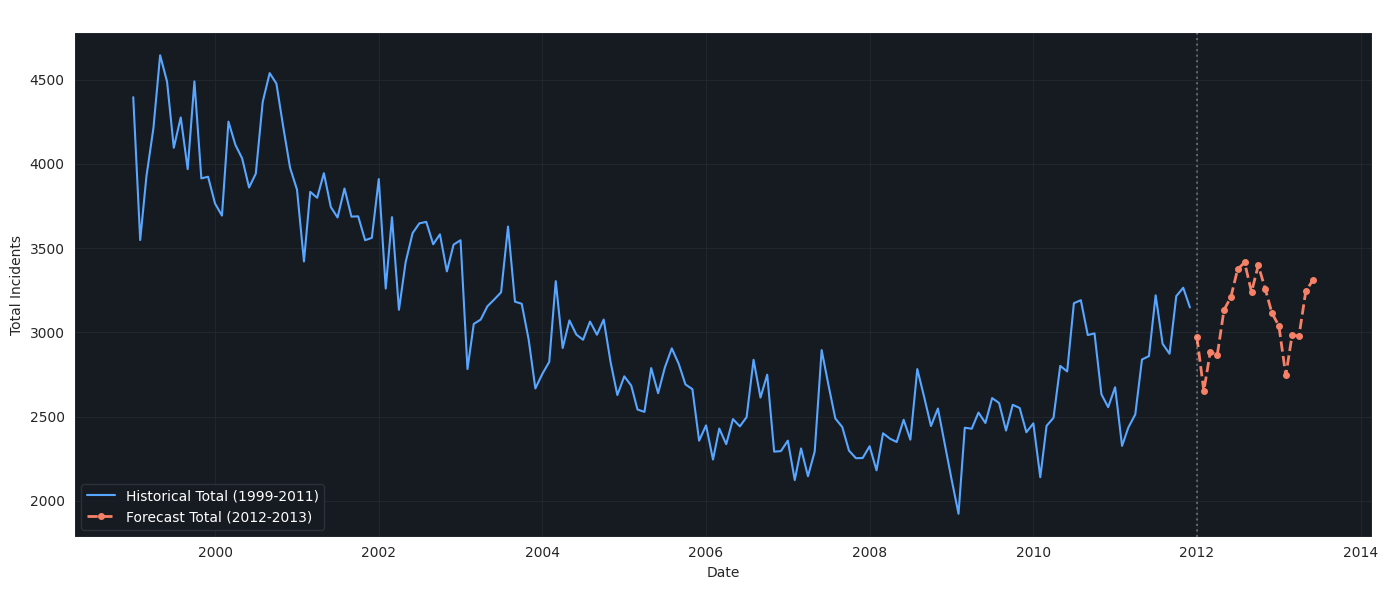

In [ ]:

# Total predicted incidents per month across all crime types (2012-2013)
monthly_total_forecast = test_filled.groupby(['YEAR','MONTH'])['Incident_Counts'].sum().reset_index()
monthly_total_forecast['Date'] = pd.to_datetime(
    monthly_total_forecast['YEAR'].astype(str) + '-' + monthly_total_forecast['MONTH'].astype(str) + '-01'
)
monthly_total_forecast = monthly_total_forecast.sort_values('Date')

monthly_total_hist = monthly.groupby('Date')['Incident_Counts'].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(monthly_total_hist['Date'], monthly_total_hist['Incident_Counts'],
        color=PALETTE[0], linewidth=1.5, label='Historical Total (1999-2011)')
ax.plot(monthly_total_forecast['Date'], monthly_total_forecast['Incident_Counts'],
        color=PALETTE[2], linewidth=2, linestyle='--', marker='o', markersize=4,
        label='Forecast Total (2012-2013)')
ax.axvline(pd.Timestamp('2012-01-01'), color='white', alpha=0.3, linestyle=':')
ax.set_title("Total Monthly Crime Incidents — Historical + Forecast", fontweight="bold", fontsize=13)
ax.set_xlabel("Date"); ax.set_ylabel("Total Incidents")
ax.legend()
plt.tight_layout()
plt.show()



## 11. Summary & Recommendations

**Model Performance**
- Both XGBoost and SARIMA were validated on a held-out year (2011) using
  recursive forecasting (matching the real prediction scenario).
- An ensemble strategy — selecting the better model **per crime type** —
  was used for the final Test.csv predictions, since some crime types
  (e.g. those with strong, clean seasonality) favor SARIMA, while others
  (with more complex or noisier patterns) benefit from XGBoost pooling
  information across all crime types.

**Operational Recommendations**
1. **Patrol Scheduling** — Crime incidents peak during specific hours and
   show clear monthly seasonality (see EDA section); patrol allocation
   should follow these temporal patterns rather than being uniform.
2. **Resource Allocation by Neighborhood** — A small number of
   neighborhoods (e.g. Central Business District, West End) account for a
   disproportionate share of incidents — geographic targeting of
   community policing and surveillance investment is justified.
3. **Type-Specific Strategy** — Since each crime type has a distinct
   seasonal signature (see the seasonality heatmap), tailored
   interventions (e.g. holiday-season anti-theft campaigns, summer
   bike-theft patrols) are more effective than one-size-fits-all policy.
4. **Model Maintenance** — As new monthly data becomes available, the
   model should be retrained periodically (e.g. quarterly) to capture
   drift in crime patterns over time.

**Next Steps**
- Incorporate exogenous features: weather, public holidays, local events,
  economic indicators (unemployment, etc.)
- Explore neighborhood-level forecasts (not just city-wide per type)
- Try Prophet or LSTM-based deep learning models for comparison
- Build confidence intervals around forecasts for better operational risk planning
